# Door Opening RL (SAC) — Visualizations\n\nThis notebook generates all figures for the project report and website.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path
from stable_baselines3 import SAC
from train_door import RobosuiteGymEnv

matplotlib.rcParams.update({"font.size": 12, "figure.dpi": 150})

# Paths
EVAL_LOG = "logs/door_sac/evaluations.npz"
CHECKPOINT_DIR = "models/door_sac_checkpoints"
BEST_MODEL = "models/door_sac/best_model"
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

print("Setup complete.")

[robosuite WARNING] No private macro file found! (macros.py:57)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:58)
[robosuite WARNING] To setup, run: python /opt/anaconda3/lib/python3.12/site-packages/robosuite/scripts/setup_macros.py (macros.py:59)
[robosuite WARNING] Could not import robosuite_models. Some robots may not be available. If you want to use these robots, please install robosuite_models from source (https://github.com/ARISE-Initiative/robosuite_models) or through pip install. (__init__.py:30)
[robosuite WARNING] Could not load the mink-based whole-body IK. Make sure you install related import properly, otherwise you will not be able to use the default IK controller setting for GR1 robot. (__init__.py:40)


Setup complete.


## 1. Training Reward Curve\nMean eval reward ± 1 std over training timesteps.

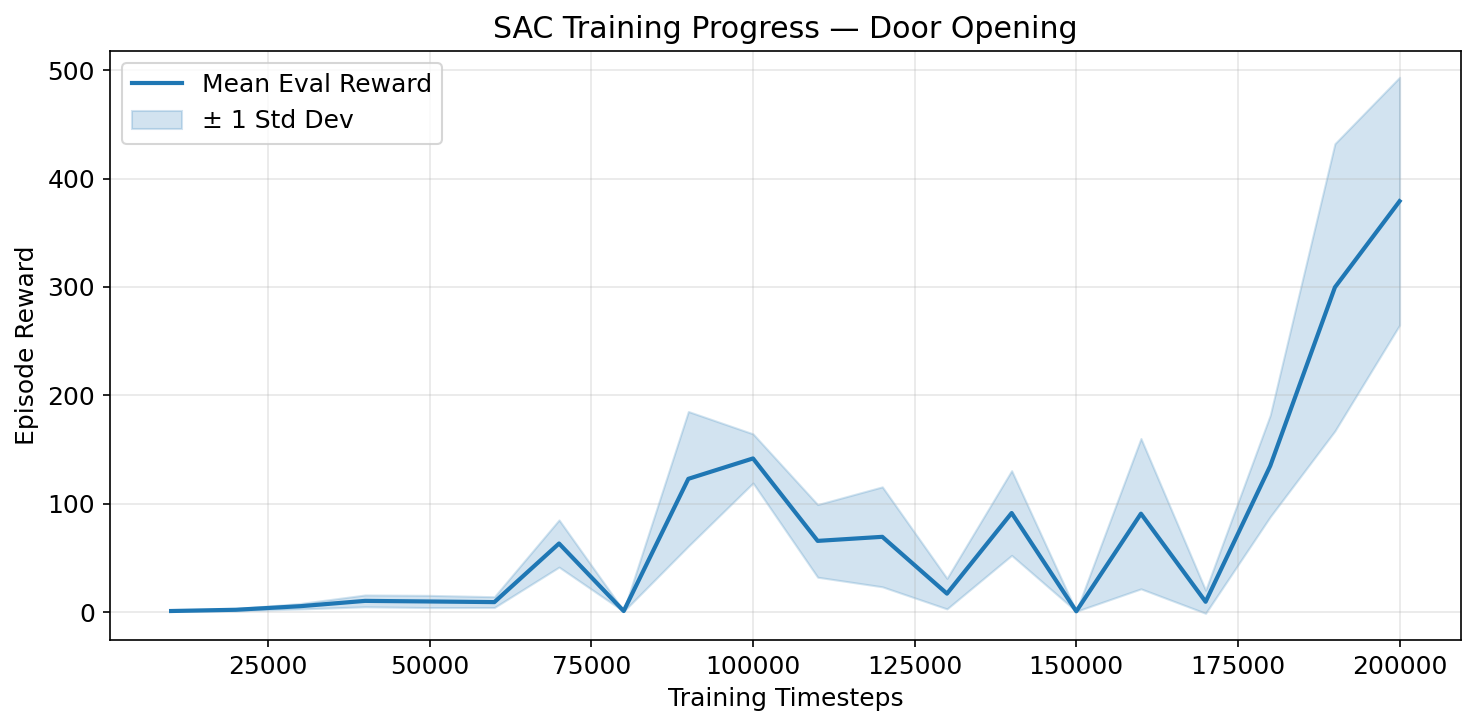

Best mean reward: 379.12 at timestep 200000


In [2]:
data = np.load(EVAL_LOG)
timesteps = data["timesteps"]
results = data["results"]  # shape: (n_evals, n_episodes)

mean_reward = results.mean(axis=1)
std_reward = results.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(timesteps, mean_reward, color="tab:blue", linewidth=2, label="Mean Eval Reward")
ax.fill_between(timesteps, mean_reward - std_reward, mean_reward + std_reward,
                alpha=0.2, color="tab:blue", label="± 1 Std Dev")
ax.set_xlabel("Training Timesteps")
ax.set_ylabel("Episode Reward")
ax.set_title("SAC Training Progress — Door Opening")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "training_reward_curve.png")
plt.show()
print(f"Best mean reward: {mean_reward.max():.2f} at timestep {timesteps[mean_reward.argmax()]}")

## 2. Episode Length Over Training\nShorter episodes = agent solving the task faster.

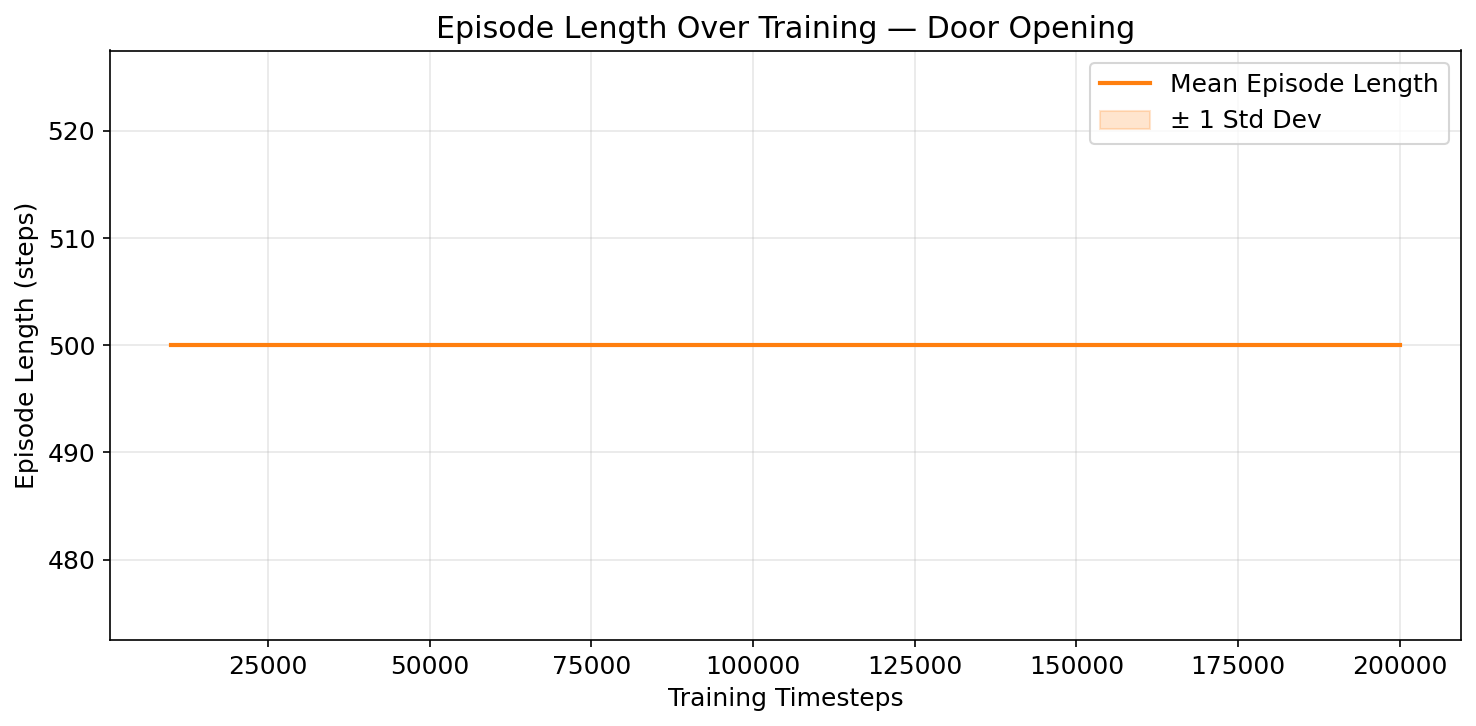

In [3]:
ep_lengths = data["ep_lengths"]  # shape: (n_evals, n_episodes)

mean_len = ep_lengths.mean(axis=1)
std_len = ep_lengths.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(timesteps, mean_len, color="tab:orange", linewidth=2, label="Mean Episode Length")
ax.fill_between(timesteps, mean_len - std_len, mean_len + std_len,
                alpha=0.2, color="tab:orange", label="± 1 Std Dev")
ax.set_xlabel("Training Timesteps")
ax.set_ylabel("Episode Length (steps)")
ax.set_title("Episode Length Over Training — Door Opening")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "episode_length_curve.png")
plt.show()

## 3. Collect Detailed Rollout Data\nRun the best model and record observations, actions, and rewards per step for downstream plots.

In [6]:
def collect_rollout(model, env, n_episodes=10):
    """Run episodes and collect per-step data."""
    episodes = []
    for ep in range(n_episodes):
        obs, _ = env.reset()
        ep_data = {"obs": [], "actions": [], "rewards": [], "gripper_pos": [], "handle_pos": []}
        done = False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            ep_data["obs"].append(obs.copy())
            ep_data["actions"].append(action.copy())

            # Grab gripper and handle positions from the underlying robosuite env
            raw_env = env.env
            gripper_pos = raw_env.sim.data.site_xpos[raw_env.sim.model.site_name2id("gripper0_right_grip_site")].copy()
            handle_pos = raw_env._handle_xpos.copy()
            ep_data["gripper_pos"].append(gripper_pos)
            ep_data["handle_pos"].append(handle_pos)

            obs, reward, terminated, truncated, info = env.step(action)
            ep_data["rewards"].append(reward)
            done = terminated or truncated

        # Convert lists to arrays
        for k in ep_data:
            ep_data[k] = np.array(ep_data[k])
        ep_data["total_reward"] = ep_data["rewards"].sum()
        episodes.append(ep_data)
        print(f"Episode {ep+1}: reward={ep_data['total_reward']:.2f}, steps={len(ep_data['rewards'])}")
    return episodes

env = RobosuiteGymEnv(render_mode=None, horizon=500)
model = SAC.load(BEST_MODEL)
episodes = collect_rollout(model, env, n_episodes=10)
env.close()
print(f"\nCollected {len(episodes)} episodes.")

[robosuite INFO] Loading controller configuration from: /opt/anaconda3/lib/python3.12/site-packages/robosuite/controllers/config/robots/default_panda.json (composite_controller_factory.py:121)
[robosuite INFO] Loading controller configuration from: /opt/anaconda3/lib/python3.12/site-packages/robosuite/controllers/config/robots/default_panda.json (composite_controller_factory.py:121)
/opt/anaconda3/lib/python3.12/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/opt/anaconda3/lib/python3.12/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
[robosuite INFO] Loading controller configuration from: /opt/anaconda3/lib/python3.12/site-packages/robosuite/controllers/config/robots/default_panda.json (composite_controller_factory.py:121)
[robosuite INFO] Loading controller configu

Episode 1: reward=162.52, steps=500


[robosuite INFO] Loading controller configuration from: /opt/anaconda3/lib/python3.12/site-packages/robosuite/controllers/config/robots/default_panda.json (composite_controller_factory.py:121)


Episode 2: reward=324.98, steps=500


[robosuite INFO] Loading controller configuration from: /opt/anaconda3/lib/python3.12/site-packages/robosuite/controllers/config/robots/default_panda.json (composite_controller_factory.py:121)


...

Episode 7: reward=421.66, steps=500


[robosuite INFO] Loading controller configuration from: /opt/anaconda3/lib/python3.12/site-packages/robosuite/controllers/config/robots/default_panda.json (composite_controller_factory.py:121)


Episode 8: reward=453.26, steps=500


[robosuite INFO] Loading controller configuration from: /opt/anaconda3/lib/python3.12/site-packages/robosuite/controllers/config/robots/default_panda.json (composite_controller_factory.py:121)


Episode 9: reward=108.35, steps=500
Episode 10: reward=451.71, steps=500

Collected 10 episodes.


## 4. Reward Decomposition Over an Episode\nShows how reaching and rotating rewards evolve over a single episode.

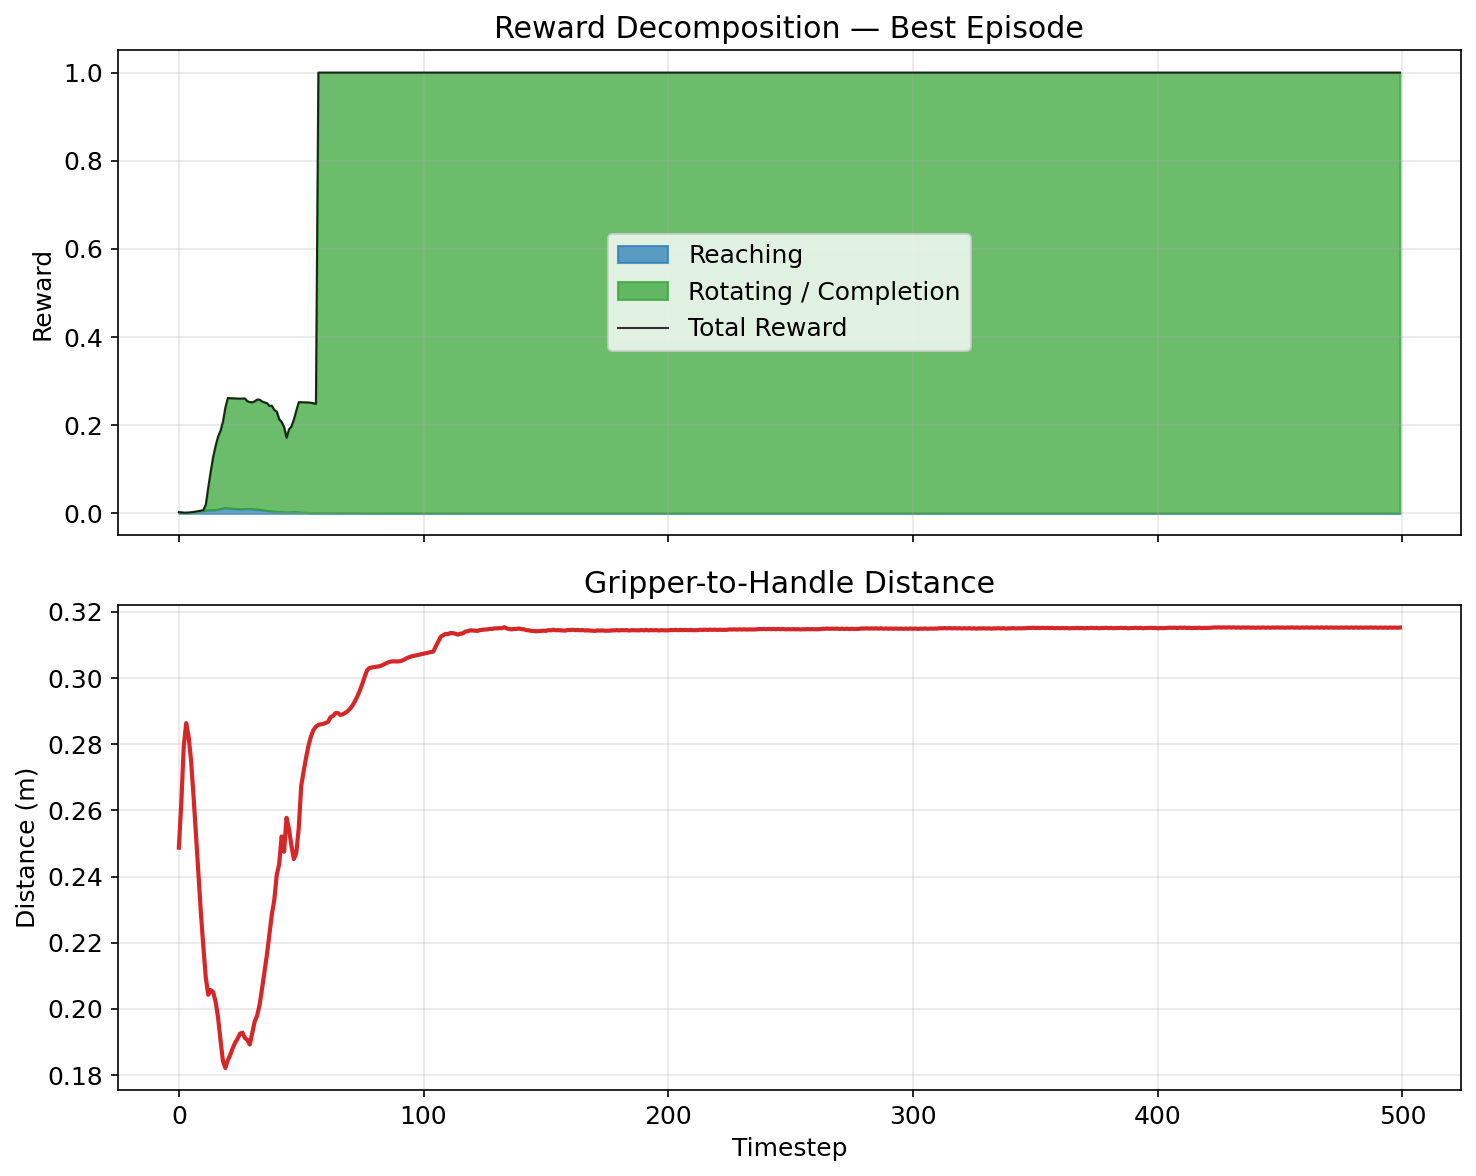

In [7]:
# Pick the best episode for a clean visualization
best_ep = max(episodes, key=lambda e: e["total_reward"])

# Decompose: reaching reward is based on gripper-to-handle distance
distances = np.linalg.norm(best_ep["gripper_pos"] - best_ep["handle_pos"], axis=1)
reaching_reward = 0.25 * (1 - np.tanh(10.0 * distances))

# Total reward per step minus reaching = rotating + completion components
other_reward = best_ep["rewards"] - reaching_reward
# Clip to avoid small negative values from floating point
other_reward = np.clip(other_reward, 0, None)

steps = np.arange(len(best_ep["rewards"]))

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Stacked reward components
axes[0].fill_between(steps, 0, reaching_reward, alpha=0.7, label="Reaching", color="tab:blue")
axes[0].fill_between(steps, reaching_reward, reaching_reward + other_reward, alpha=0.7,
                     label="Rotating / Completion", color="tab:green")
axes[0].plot(steps, best_ep["rewards"], color="black", linewidth=1, label="Total Reward", alpha=0.8)
axes[0].set_ylabel("Reward")
axes[0].set_title("Reward Decomposition — Best Episode")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gripper-to-handle distance
axes[1].plot(steps, distances, color="tab:red", linewidth=2)
axes[1].set_xlabel("Timestep")
axes[1].set_ylabel("Distance (m)")
axes[1].set_title("Gripper-to-Handle Distance")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(FIG_DIR / "reward_decomposition.png")
plt.show()

## 5. End-Effector (Gripper) Trajectory — 3D\nShows the gripper's path through space. Multiple episodes overlaid.

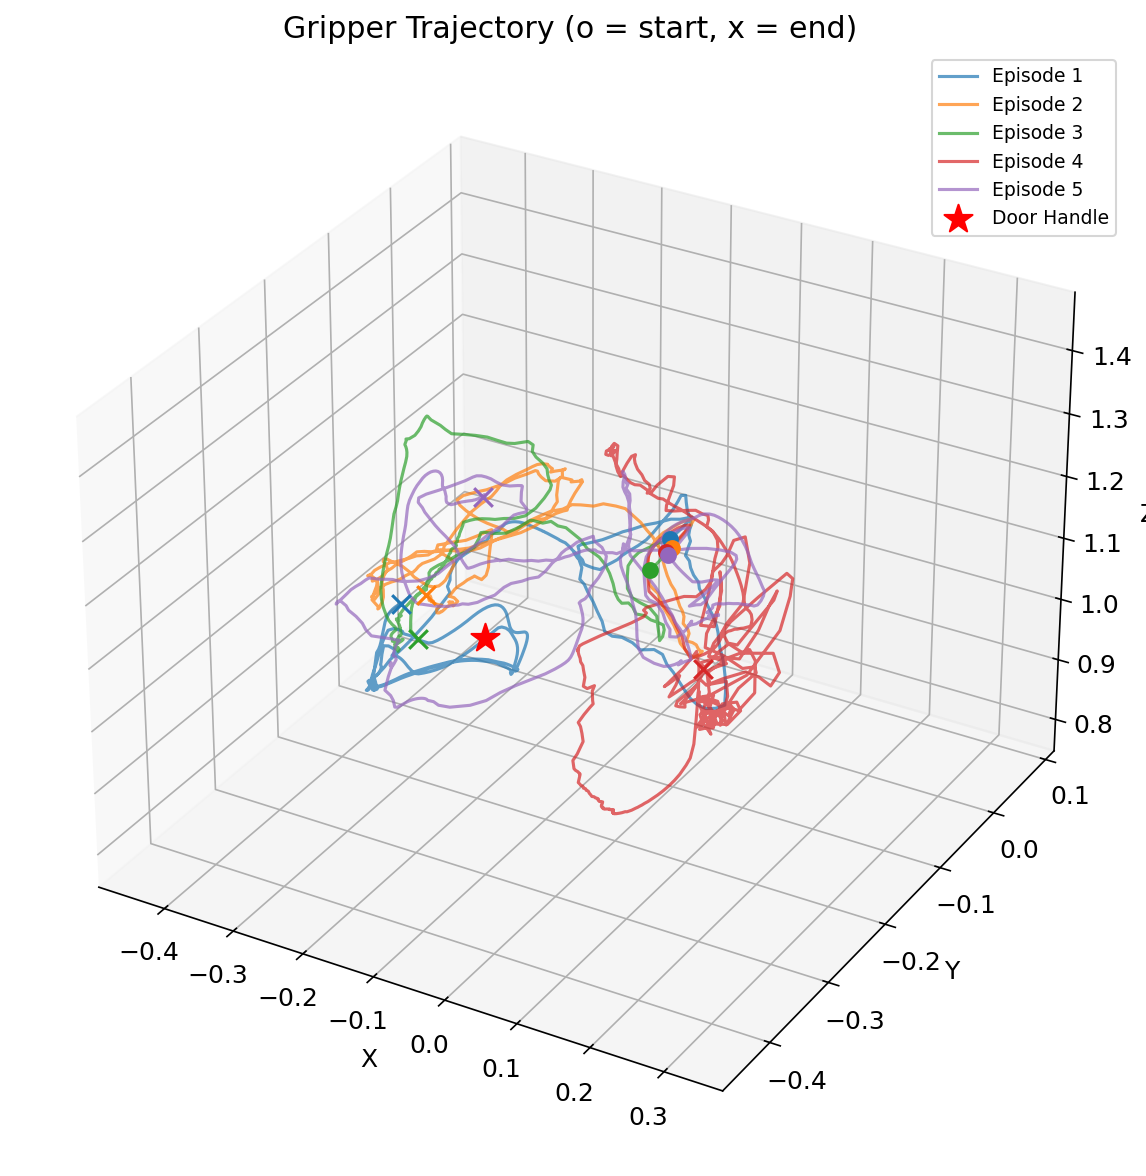

In [8]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

cmap = plt.cm.tab10
for i, ep in enumerate(episodes[:5]):
    gpos = ep["gripper_pos"]
    ax.plot(gpos[:, 0], gpos[:, 1], gpos[:, 2], color=cmap(i), linewidth=1.5,
            alpha=0.7, label=f"Episode {i+1}")
    ax.scatter(*gpos[0], color=cmap(i), marker="o", s=50, zorder=5)   # start
    ax.scatter(*gpos[-1], color=cmap(i), marker="x", s=80, zorder=5)  # end

# Mark handle position (from first episode, first step — approximately fixed)
hpos = episodes[0]["handle_pos"][0]
ax.scatter(*hpos, color="red", marker="*", s=200, zorder=10, label="Door Handle")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Gripper Trajectory (o = start, x = end)")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "gripper_trajectory_3d.png")
plt.show()

## 6. Action Heatmap\nJoint actions over time for a single episode. Shows how the policy coordinates the arm.

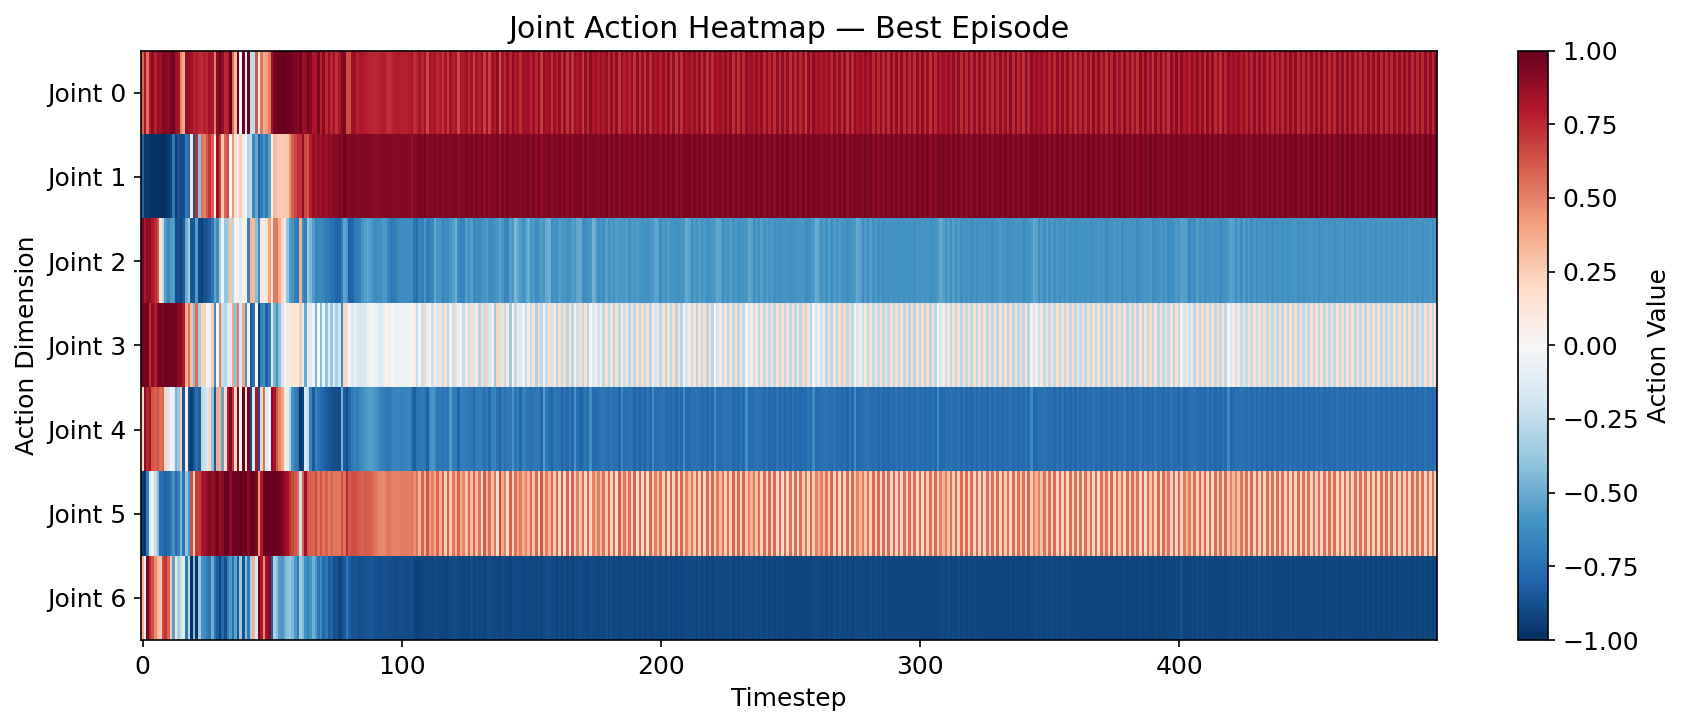

In [9]:
actions = best_ep["actions"]  # shape: (T, action_dim)

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(actions.T, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1,
               interpolation="nearest")
ax.set_xlabel("Timestep")
ax.set_ylabel("Action Dimension")
ax.set_title("Joint Action Heatmap — Best Episode")
ax.set_yticks(range(actions.shape[1]))
ax.set_yticklabels([f"Joint {i}" for i in range(actions.shape[1])])
cbar = fig.colorbar(im, ax=ax, label="Action Value")
fig.tight_layout()
fig.savefig(FIG_DIR / "action_heatmap.png")
plt.show()

## 7. Checkpoint Comparison\nCompare policy performance at different training stages (50k, 100k, 150k, 200k steps).

[robosuite INFO] Loading controller configuration from: /opt/anaconda3/lib/python3.12/site-packages/robosuite/controllers/config/robots/default_panda.json (composite_controller_factory.py:121)
[robosuite INFO] Loading controller configuration from: /opt/anaconda3/lib/python3.12/site-packages/robosuite/controllers/config/robots/default_panda.json (composite_controller_factory.py:121)
/opt/anaconda3/lib/python3.12/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/opt/anaconda3/lib/python3.12/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
[robosuite INFO] Loading controller configuration from: /opt/anaconda3/lib/python3.12/site-packages/robosuite/controllers/config/robots/default_panda.json (composite_controller_factory.py:121)
[robosuite INFO] Loading controller configu

Checkpoint 50000: mean_reward=36.31, success_rate=30%


[robosuite INFO] Loading controller configuration from: /opt/anaconda3/lib/python3.12/site-packages/robosuite/controllers/config/robots/default_panda.json (composite_controller_factory.py:121)
[robosuite INFO] Loading controller configuration from: /opt/anaconda3/lib/python3.12/site-packages/robosuite/controllers/config/robots/default_panda.json (composite_controller_factory.py:121)
[robosuite INFO] Loading controller configuration from: /opt/anaconda3/lib/python3.12/site-packages/robosuite/controllers/config/robots/default_panda.json (composite_controller_factory.py:121)
[robosuite INFO] Loading controller configuration from: /opt/anaconda3/lib/python3.12/site-packages/robosuite/controllers/config/robots/default_panda.json (composite_controller_factory.py:121)
[robosuite INFO] Loading controller configuration from: /opt/anaconda3/lib/python3.12/site-packages/robosuite/controllers/config/robots/default_panda.json (composite_controller_factory.py:121)
[robosuite INFO] Loading controller

Checkpoint 100000: mean_reward=131.21, success_rate=100%


[robosuite INFO] Loading controller configuration from: /opt/anaconda3/lib/python3.12/site-packages/robosuite/controllers/config/robots/default_panda.json (composite_controller_factory.py:121)
[robosuite INFO] Loading controller configuration from: /opt/anaconda3/lib/python3.12/site-packages/robosuite/controllers/config/robots/default_panda.json (composite_controller_factory.py:121)
[robosuite INFO] Loading controller configuration from: /opt/anaconda3/lib/python3.12/site-packages/robosuite/controllers/config/robots/default_panda.json (composite_controller_factory.py:121)
[robosuite INFO] Loading controller configuration from: /opt/anaconda3/lib/python3.12/site-packages/robosuite/controllers/config/robots/default_panda.json (composite_controller_factory.py:121)
[robosuite INFO] Loading controller configuration from: /opt/anaconda3/lib/python3.12/site-packages/robosuite/controllers/config/robots/default_panda.json (composite_controller_factory.py:121)
[robosuite INFO] Loading controller

Checkpoint 150000: mean_reward=0.74, success_rate=0%


[robosuite INFO] Loading controller configuration from: /opt/anaconda3/lib/python3.12/site-packages/robosuite/controllers/config/robots/default_panda.json (composite_controller_factory.py:121)
[robosuite INFO] Loading controller configuration from: /opt/anaconda3/lib/python3.12/site-packages/robosuite/controllers/config/robots/default_panda.json (composite_controller_factory.py:121)
[robosuite INFO] Loading controller configuration from: /opt/anaconda3/lib/python3.12/site-packages/robosuite/controllers/config/robots/default_panda.json (composite_controller_factory.py:121)
[robosuite INFO] Loading controller configuration from: /opt/anaconda3/lib/python3.12/site-packages/robosuite/controllers/config/robots/default_panda.json (composite_controller_factory.py:121)
[robosuite INFO] Loading controller configuration from: /opt/anaconda3/lib/python3.12/site-packages/robosuite/controllers/config/robots/default_panda.json (composite_controller_factory.py:121)
[robosuite INFO] Loading controller

Checkpoint 200000: mean_reward=361.21, success_rate=90%


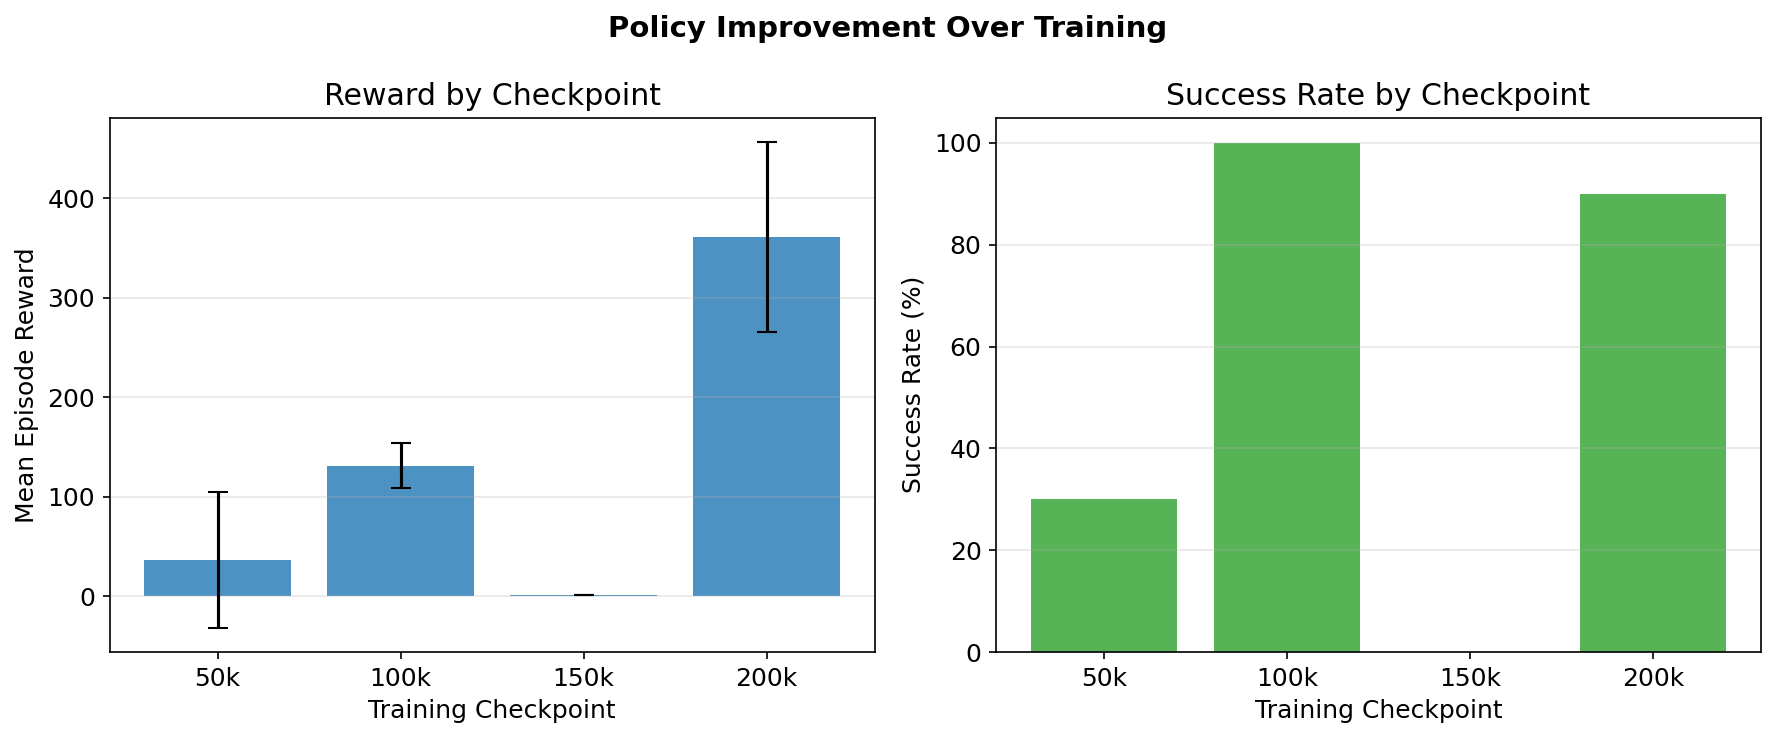

In [10]:
checkpoint_steps = [50_000, 100_000, 150_000, 200_000]
checkpoint_results = {}

env = RobosuiteGymEnv(render_mode=None, horizon=500)

for step in checkpoint_steps:
    ckpt_path = f"{CHECKPOINT_DIR}/door_{step}_steps"
    ckpt_model = SAC.load(ckpt_path)
    rewards = []
    successes = []
    for _ in range(10):
        obs, _ = env.reset()
        total_r = 0
        done = False
        success = False
        while not done:
            action, _ = ckpt_model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            total_r += reward
            if reward >= 1.0:
                success = True
            done = terminated or truncated
        rewards.append(total_r)
        successes.append(success)
    checkpoint_results[step] = {"rewards": rewards, "success_rate": np.mean(successes)}
    print(f"Checkpoint {step}: mean_reward={np.mean(rewards):.2f}, success_rate={np.mean(successes)*100:.0f}%")

env.close()

# Bar chart
steps_labels = [f"{s//1000}k" for s in checkpoint_steps]
mean_rewards = [np.mean(checkpoint_results[s]["rewards"]) for s in checkpoint_steps]
std_rewards = [np.std(checkpoint_results[s]["rewards"]) for s in checkpoint_steps]
success_rates = [checkpoint_results[s]["success_rate"] * 100 for s in checkpoint_steps]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(steps_labels, mean_rewards, yerr=std_rewards, capsize=5, color="tab:blue", alpha=0.8)
axes[0].set_xlabel("Training Checkpoint")
axes[0].set_ylabel("Mean Episode Reward")
axes[0].set_title("Reward by Checkpoint")
axes[0].grid(True, alpha=0.3, axis="y")

axes[1].bar(steps_labels, success_rates, color="tab:green", alpha=0.8)
axes[1].set_xlabel("Training Checkpoint")
axes[1].set_ylabel("Success Rate (%)")
axes[1].set_title("Success Rate by Checkpoint")
axes[1].set_ylim(0, 105)
axes[1].grid(True, alpha=0.3, axis="y")

fig.suptitle("Policy Improvement Over Training", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "checkpoint_comparison.png")
plt.show()

## 8. Evaluation Summary Table\nFinal metrics for the best model over many episodes.

  EVALUATION SUMMARY (Best Model, 10 Episodes)
  Mean Reward:      303.01 ± 149.46
  Max Reward:       453.26
  Min Reward:       26.03
  Success Rate:     90%
  Mean Ep Length:   500 ± 0 steps
  Min Ep Length:    500 steps


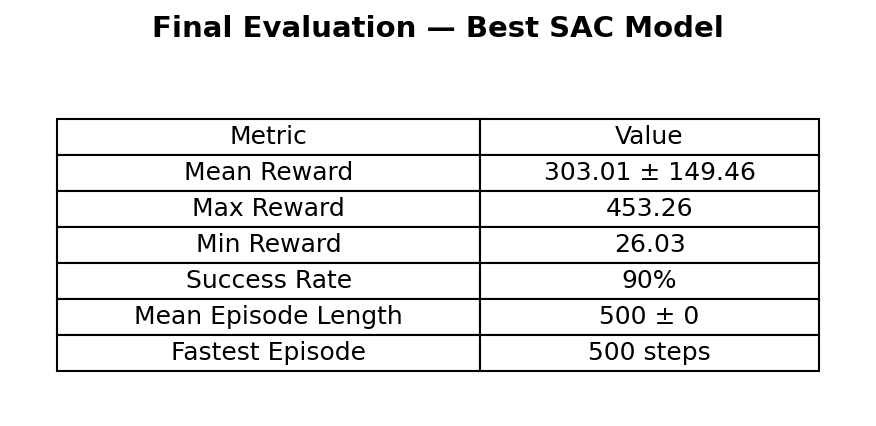

In [11]:
total_rewards = [ep["total_reward"] for ep in episodes]
ep_lengths = [len(ep["rewards"]) for ep in episodes]
successes = [ep["rewards"].max() >= 1.0 for ep in episodes]

print("=" * 50)
print("  EVALUATION SUMMARY (Best Model, 10 Episodes)")
print("=" * 50)
print(f"  Mean Reward:      {np.mean(total_rewards):.2f} ± {np.std(total_rewards):.2f}")
print(f"  Max Reward:       {np.max(total_rewards):.2f}")
print(f"  Min Reward:       {np.min(total_rewards):.2f}")
print(f"  Success Rate:     {np.mean(successes)*100:.0f}%")
print(f"  Mean Ep Length:   {np.mean(ep_lengths):.0f} ± {np.std(ep_lengths):.0f} steps")
print(f"  Min Ep Length:    {np.min(ep_lengths)} steps")
print("=" * 50)

# Also save as a figure (table)
fig, ax = plt.subplots(figsize=(6, 3))
ax.axis("off")
table_data = [
    ["Mean Reward", f"{np.mean(total_rewards):.2f} ± {np.std(total_rewards):.2f}"],
    ["Max Reward", f"{np.max(total_rewards):.2f}"],
    ["Min Reward", f"{np.min(total_rewards):.2f}"],
    ["Success Rate", f"{np.mean(successes)*100:.0f}%"],
    ["Mean Episode Length", f"{np.mean(ep_lengths):.0f} ± {np.std(ep_lengths):.0f}"],
    ["Fastest Episode", f"{np.min(ep_lengths)} steps"],
]
table = ax.table(cellText=table_data, colLabels=["Metric", "Value"],
                 cellLoc="center", loc="center", colWidths=[0.5, 0.4])
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 1.5)
ax.set_title("Final Evaluation — Best SAC Model", fontsize=14, fontweight="bold", pad=20)
fig.tight_layout()
fig.savefig(FIG_DIR / "evaluation_table.png", bbox_inches="tight")
plt.show()

## 9. Rollout Consistency\nOverlay gripper-to-handle distance across multiple episodes to show policy stability.

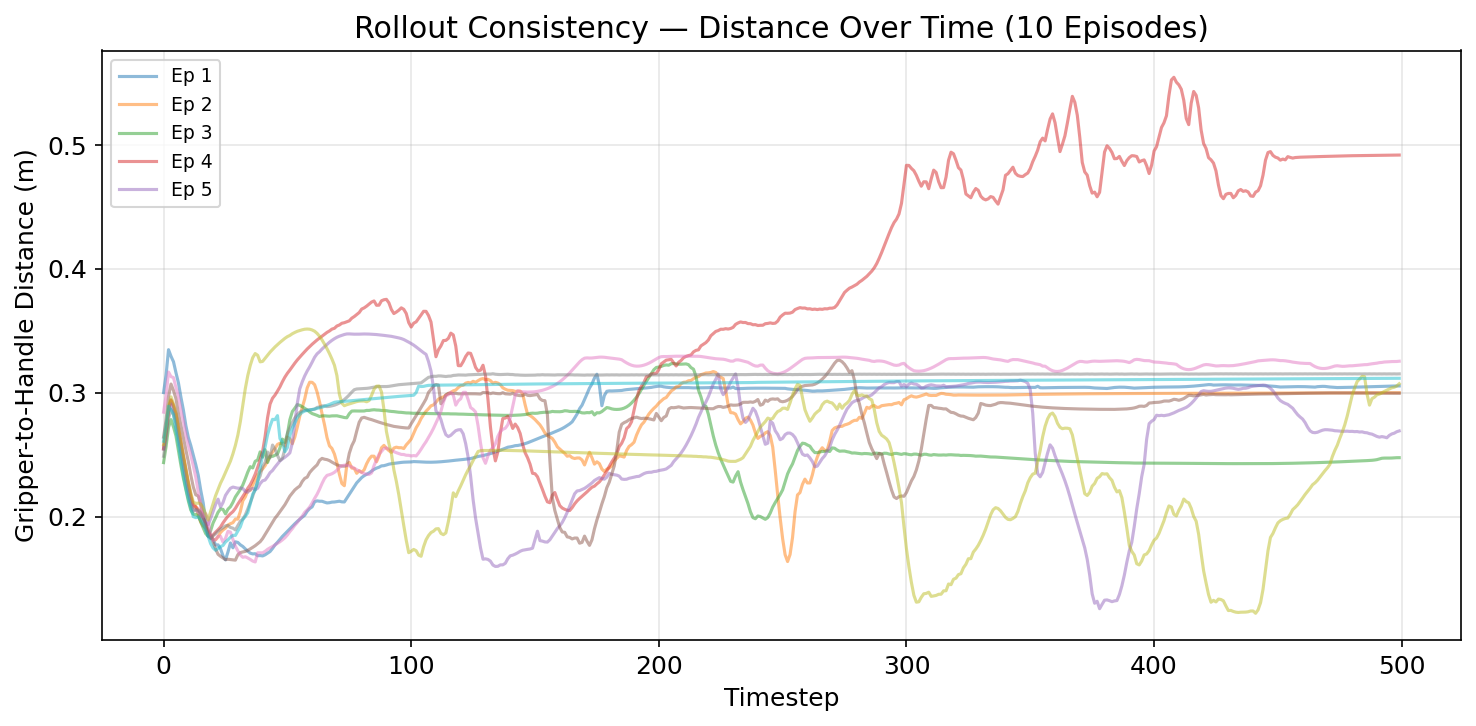

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

for i, ep in enumerate(episodes):
    dist = np.linalg.norm(ep["gripper_pos"] - ep["handle_pos"], axis=1)
    ax.plot(dist, alpha=0.5, linewidth=1.5, label=f"Ep {i+1}" if i < 5 else None)

ax.set_xlabel("Timestep")
ax.set_ylabel("Gripper-to-Handle Distance (m)")
ax.set_title("Rollout Consistency — Distance Over Time (10 Episodes)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "rollout_consistency.png")
plt.show()

---\n# Interactive Visualizations\nRequires `plotly` and `ipywidgets`. Install with:\n```\npip install plotly ipywidgets\n```

In [13]:
import plotly.graph_objects as go
from ipywidgets import interact, IntSlider

## 10. Interactive Training Curve\nHover over any point to see exact reward and timestep values.

In [14]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=timesteps, y=mean_reward, mode="lines",
    name="Mean Eval Reward",
    line=dict(color="royalblue", width=2),
    hovertemplate="Timestep: %{x:,}<br>Mean Reward: %{y:.2f}<extra></extra>",
))
fig.add_trace(go.Scatter(
    x=np.concatenate([timesteps, timesteps[::-1]]),
    y=np.concatenate([mean_reward + std_reward, (mean_reward - std_reward)[::-1]]),
    fill="toself", fillcolor="rgba(65,105,225,0.15)",
    line=dict(color="rgba(255,255,255,0)"),
    name="± 1 Std Dev", hoverinfo="skip",
))
fig.update_layout(
    title="SAC Training Progress — Door Opening (Interactive)",
    xaxis_title="Training Timesteps",
    yaxis_title="Episode Reward",
    hovermode="x unified",
    template="plotly_white",
    width=900, height=450,
)
fig.show()

## 11. Interactive 3D Gripper Trajectory\nClick and drag to rotate. Scroll to zoom. Hover for coordinates.

In [15]:
fig = go.Figure()

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
for i, ep in enumerate(episodes[:5]):
    gpos = ep["gripper_pos"]
    t = np.arange(len(gpos))
    fig.add_trace(go.Scatter3d(
        x=gpos[:, 0], y=gpos[:, 1], z=gpos[:, 2],
        mode="lines", name=f"Episode {i+1}",
        line=dict(color=colors[i], width=4),
        hovertemplate="t=%{customdata}<br>x=%{x:.3f}<br>y=%{y:.3f}<br>z=%{z:.3f}<extra>Ep %{fullData.name}</extra>",
        customdata=t,
    ))
    # Start marker
    fig.add_trace(go.Scatter3d(
        x=[gpos[0, 0]], y=[gpos[0, 1]], z=[gpos[0, 2]],
        mode="markers", marker=dict(size=5, color=colors[i], symbol="circle"),
        showlegend=False, hoverinfo="skip",
    ))
    # End marker
    fig.add_trace(go.Scatter3d(
        x=[gpos[-1, 0]], y=[gpos[-1, 1]], z=[gpos[-1, 2]],
        mode="markers", marker=dict(size=5, color=colors[i], symbol="x"),
        showlegend=False, hoverinfo="skip",
    ))

# Door handle
hpos = episodes[0]["handle_pos"][0]
fig.add_trace(go.Scatter3d(
    x=[hpos[0]], y=[hpos[1]], z=[hpos[2]],
    mode="markers", marker=dict(size=8, color="red", symbol="diamond"),
    name="Door Handle",
))

fig.update_layout(
    title="Gripper Trajectory — Interactive 3D (o=start, x=end)",
    scene=dict(xaxis_title="X", yaxis_title="Y", zaxis_title="Z"),
    template="plotly_white",
    width=800, height=700,
)
fig.show()

## 12. Checkpoint Slider\nUse the slider to scrub through training stages. Shows the gripper-to-handle distance profile at each checkpoint.

In [16]:
# Pre-collect one rollout per checkpoint for the slider
slider_data = {}
env = RobosuiteGymEnv(render_mode=None, horizon=500)

for step in checkpoint_steps:
    ckpt_path = f"{CHECKPOINT_DIR}/door_{step}_steps"
    ckpt_model = SAC.load(ckpt_path)
    obs, _ = env.reset()
    gripper_positions = []
    handle_positions = []
    rewards = []
    done = False
    while not done:
        action, _ = ckpt_model.predict(obs, deterministic=True)
        raw_env = env.env
        gripper_positions.append(
            raw_env.sim.data.site_xpos[raw_env.sim.model.site_name2id("gripper0_right_grip_site")].copy()
        )
        handle_positions.append(raw_env._handle_xpos.copy())
        obs, reward, terminated, truncated, info = env.step(action)
        rewards.append(reward)
        done = terminated or truncated
    slider_data[step] = {
        "gripper_pos": np.array(gripper_positions),
        "handle_pos": np.array(handle_positions),
        "rewards": np.array(rewards),
    }
    print(f"Checkpoint {step}: {len(rewards)} steps, reward={sum(rewards):.2f}")

env.close()
print("Slider data collected.")

[robosuite INFO] Loading controller configuration from: /opt/anaconda3/lib/python3.12/site-packages/robosuite/controllers/config/robots/default_panda.json (composite_controller_factory.py:121)
[robosuite INFO] Loading controller configuration from: /opt/anaconda3/lib/python3.12/site-packages/robosuite/controllers/config/robots/default_panda.json (composite_controller_factory.py:121)
/opt/anaconda3/lib/python3.12/site-packages/gymnasium/spaces/box.py:236: UserWarning:

WARN: Box low's precision lowered by casting to float32, current low.dtype=float64

/opt/anaconda3/lib/python3.12/site-packages/gymnasium/spaces/box.py:306: UserWarning:

WARN: Box high's precision lowered by casting to float32, current high.dtype=float64

[robosuite INFO] Loading controller configuration from: /opt/anaconda3/lib/python3.12/site-packages/robosuite/controllers/config/robots/default_panda.json (composite_controller_factory.py:121)
[robosuite INFO] Loading controller configuration from: /opt/anaconda3/lib/py

Checkpoint 50000: 500 steps, reward=12.36


[robosuite INFO] Loading controller configuration from: /opt/anaconda3/lib/python3.12/site-packages/robosuite/controllers/config/robots/default_panda.json (composite_controller_factory.py:121)


Checkpoint 100000: 500 steps, reward=108.94


[robosuite INFO] Loading controller configuration from: /opt/anaconda3/lib/python3.12/site-packages/robosuite/controllers/config/robots/default_panda.json (composite_controller_factory.py:121)


Checkpoint 150000: 500 steps, reward=0.75
Checkpoint 200000: 500 steps, reward=265.08
Slider data collected.


In [17]:
def plot_checkpoint(ckpt_idx=0):
    step = checkpoint_steps[ckpt_idx]
    d = slider_data[step]
    dist = np.linalg.norm(d["gripper_pos"] - d["handle_pos"], axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Distance plot
    axes[0].plot(dist, color="tab:red", linewidth=2)
    axes[0].set_xlabel("Timestep")
    axes[0].set_ylabel("Distance (m)")
    axes[0].set_title(f"Gripper-to-Handle Distance — {step//1000}k steps")
    axes[0].set_ylim(0, max(dist.max() * 1.1, 0.5))
    axes[0].grid(True, alpha=0.3)

    # Reward plot
    axes[1].plot(d["rewards"], color="tab:blue", linewidth=2)
    axes[1].set_xlabel("Timestep")
    axes[1].set_ylabel("Reward")
    axes[1].set_title(f"Per-Step Reward — {step//1000}k steps (total: {d['rewards'].sum():.1f})")
    axes[1].grid(True, alpha=0.3)

    fig.suptitle(f"Checkpoint: {step:,} training steps", fontsize=14, fontweight="bold")
    fig.tight_layout()
    plt.show()

interact(
    plot_checkpoint,
    ckpt_idx=IntSlider(min=0, max=len(checkpoint_steps)-1, step=1, value=0,
                       description="Checkpoint:",
                       style={"description_width": "initial"},
                       readout=False),
)

interactive(children=(IntSlider(value=0, description='Checkpoint:', max=3, readout=False, style=SliderStyle(de…

<function __main__.plot_checkpoint(ckpt_idx=0)>